<a href="https://colab.research.google.com/github/VainaviS/EndoNet/blob/main/notebooks/yolov8v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.5 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

import zipfile

zip_path = list(uploaded.keys())[0]
extract_path = "/content/glenda"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Saving Glenda_v1.5_classes.zip to Glenda_v1.5_classes.zip


In [ ]:
import json, os

json_path = "/content/glenda/Glenda_v1.5_classes/coco.json"

with open(json_path) as f:
    data = json.load(f)

print("Keys:", data.keys())

# Map image_id → image info
images = {img["id"]: img for img in data["images"]}

cat_map = {cat["id"]: i for i, cat in enumerate(data["categories"])}

print("Category mapping:", cat_map)

Keys: dict_keys(['info', 'categories', 'images', 'annotations'])
Category mapping: {1: 0, 2: 1, 3: 2, 4: 3}


In [ ]:
label_dir = "/content/glenda/labels"
os.makedirs(label_dir, exist_ok=True)

for ann in data["annotations"]:
    img_id = ann["image_id"]
    img_info = images[img_id]

    file_name = os.path.splitext(img_info["file_name"])[0]
    width = img_info["width"]
    height = img_info["height"]

    # COCO bbox
    x, y, w, h = ann["bbox"]

    # Convert to YOLO format
    x_center = (x + w/2) / width
    y_center = (y + h/2) / height
    w /= width
    h /= height

    class_id = cat_map[ann["category_id"]]

    label_path = os.path.join(label_dir, file_name + ".txt")

    with open(label_path, "a") as f:
        f.write(f"{class_id} {x_center} {y_center} {w} {h}\n")

print("Conversion done!")

Conversion done!


In [ ]:
import shutil

src = "/content/glenda/Glenda_v1.5_classes/frames"
dst = "/content/glenda/images"

os.makedirs(dst, exist_ok=True)

for file in os.listdir(src):
    shutil.copy(os.path.join(src, file), os.path.join(dst, file))

print("Images moved!")

Images moved!


In [ ]:
files = os.listdir("/content/glenda/labels")
print("Total label files:", len(files))

# Check one file
with open("/content/glenda/labels/" + files[0]) as f:
    print(f.read())

Total label files: 373
0 0.75234375 0.6069444444444444 0.0734375 0.10833333333333334
0 0.84765625 0.49444444444444446 0.1453125 0.2222222222222222



In [ ]:
import random

img_dir = "/content/glenda/images"
lbl_dir = "/content/glenda/labels"

images = os.listdir(img_dir)
random.shuffle(images)

split = int(0.8 * len(images))

for split_name, split_list in zip(["train", "val"], [images[:split], images[split:]]):
    os.makedirs(f"/content/glenda/images/{split_name}", exist_ok=True)
    os.makedirs(f"/content/glenda/labels/{split_name}", exist_ok=True)

    for img in split_list:
        base = os.path.splitext(img)[0]
        lbl = base + ".txt"

        if os.path.exists(f"{lbl_dir}/{lbl}"):
            shutil.copy(f"{img_dir}/{img}", f"/content/glenda/images/{split_name}/{img}")
            shutil.copy(f"{lbl_dir}/{lbl}", f"/content/glenda/labels/{split_name}/{lbl}")

In [ ]:
import yaml

data_yaml = {
    'path': '/content/glenda',
    'train': 'images/train',
    'val': 'images/val',
    'names': {
        0: 'peritoneum',
        1: 'ovary',
        2: 'tie',
        3: 'uterus'
    }
}

with open('/content/glenda/data.yaml', 'w') as f:
    yaml.dump(data_yaml, f)

data.yaml created!


In [ ]:
!ls /content/glenda/labels/train | wc -l
!ls /content/glenda/images/train | wc -l

458
458


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8l.pt')

model.train(
    data='/content/glenda/data.yaml',
    epochs=150,
    imgsz=640,
    batch=16,
    augment=True,
    patience=30,
    project="glenda_bbox",
    name="lesion",
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0
)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/glenda/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=lesion3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bd43ef56030>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
Model summary (fused): 113 layers, 43,609,692 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4726.3±1710.2 MB/s, size: 69.5 KB)
val: Scanning /content/glenda/labels/val.cache... 76 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 76/76 39.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 11.3it/s 0.4s
                   all         76        108      0.541       0.18      0.159     0.0724
            peritoneum         50         75      0.447       0.12      0.147     0.0445
                 ovary         16         17      0.475      0.294      0.231      0.118
                   tie         12         13      0.243      0.308      0.256      0.127
                uterus          2          3          1          0          0          0
Speed: 0.5ms pr

In [ ]:
model.predict(
    source='/content/glenda/images/val',
    save=True,
    conf=0.25
)


image 1/76 /content/glenda/images/val/c_108_v_(video_3312.mp4)_f_619.jpg: 384x640 (no detections), 17.6ms
image 2/76 /content/glenda/images/val/c_117_v_(video_3530.mp4)_f_811.jpg: 384x640 2 peritoneums, 4.7ms
image 3/76 /content/glenda/images/val/c_120_v_(video_3599.mp4)_f_39.jpg: 384x640 (no detections), 4.7ms
image 4/76 /content/glenda/images/val/c_121_v_(video_3630.mp4)_f_37.jpg: 384x640 1 tie, 4.7ms
image 5/76 /content/glenda/images/val/c_12_v_(video_364.mp4)_f_253.jpg: 384x640 (no detections), 4.7ms
image 6/76 /content/glenda/images/val/c_14_v_(video_422.mp4)_f_59.jpg: 384x640 3 peritoneums, 1 tie, 4.7ms
image 7/76 /content/glenda/images/val/c_14_v_(video_425.mp4)_f_118.jpg: 384x640 1 peritoneum, 4.7ms
image 8/76 /content/glenda/images/val/c_150_v_(video_4518.mp4)_f_28.jpg: 384x640 1 peritoneum, 1 ovary, 4.7ms
image 9/76 /content/glenda/images/val/c_165_v_(video_5035.mp4)_f_13.jpg: 384x640 1 ovary, 4.7ms
image 10/76 /content/glenda/images/val/c_169_v_(video_5211.mp4)_f_104.jpg: 3

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'peritoneum', 1: 'ovary', 2: 'tie', 3: 'uterus'}
 obb: None
 orig_img: array([[[  0,   4,   7],
         [  1,  15,  21],
         [  7,  18,  32],
         ...,
         [ 34,  33,  65],
         [ 42,  42,  72],
         [ 39,  39,  69]],
 
        [[  0,  11,  17],
         [  2,  15,  23],
         [  9,  20,  34],
         ...,
         [ 36,  35,  67],
         [ 43,  43,  73],
         [ 40,  40,  70]],
 
        [[  4,  17,  25],
         [  4,  16,  26],
         [ 14,  24,  41],
         ...,
         [ 36,  35,  67],
         [ 42,  42,  72],
         [ 42,  42,  72]],
 
        ...,
 
        [[ 85,  85,  99],
         [ 65,  65,  79],
         [ 62,  62,  76],
         ...,
         [ 88,  84, 103],
         [ 89,  83, 102],
         [ 89,  85, 104]],
 
        [[ 14,  13,  22],
         [  3,   2,  11],
         [  4,   4,

In [ ]:
from ultralytics import YOLO

model = YOLO('runs/detect/glenda_bbox/lesion/weights/best.pt')

results = model.predict(
    source='/content/glenda/images/val',
    conf=0.25,
    save=False,
    stream=True
)

In [ ]:
import os
from collections import defaultdict

label_dir = "/content/glenda/labels/val"
image_dir = "/content/glenda/images/val"

class_names = {
    0: 'Peritoneum',
    1: 'Ovary',
    2: 'TIE',
    3: 'Uterus'
}

selected_images = {}

for lbl_file in os.listdir(label_dir):
    lbl_path = os.path.join(label_dir, lbl_file)

    with open(lbl_path) as f:
        classes = set(int(line.split()[0]) for line in f if line.strip())

    for cls in classes:
        if cls not in selected_images:
            img_name = lbl_file.replace(".txt", ".jpg")
            img_path = os.path.join(image_dir, img_name)

            if os.path.exists(img_path):
                selected_images[cls] = img_path

    if len(selected_images) == 4:
        break

print(selected_images)

{2: '/content/glenda/images/val/c_121_v_(video_3630.mp4)_f_37.jpg', 1: '/content/glenda/images/val/c_44_v_(video_1373.mp4)_f_215.jpg', 0: '/content/glenda/images/val/c_117_v_(video_3530.mp4)_f_811.jpg', 3: '/content/glenda/images/val/c_85_v_(video_2607.mp4)_f_733.jpg'}


In [ ]:
images_list = list(selected_images.values())

results = model.predict(
    source=images_list,
    conf=0.25,
    save=False
)


0: 288x512 1 tie, 4.6ms
1: 288x512 1 peritoneum, 1 ovary, 4.6ms
2: 288x512 1 peritoneum, 4.6ms
3: 288x512 1 tie, 1 uterus, 4.6ms
Speed: 0.4ms preprocess, 4.6ms inference, 0.3ms postprocess per image at shape (1, 3, 288, 512)


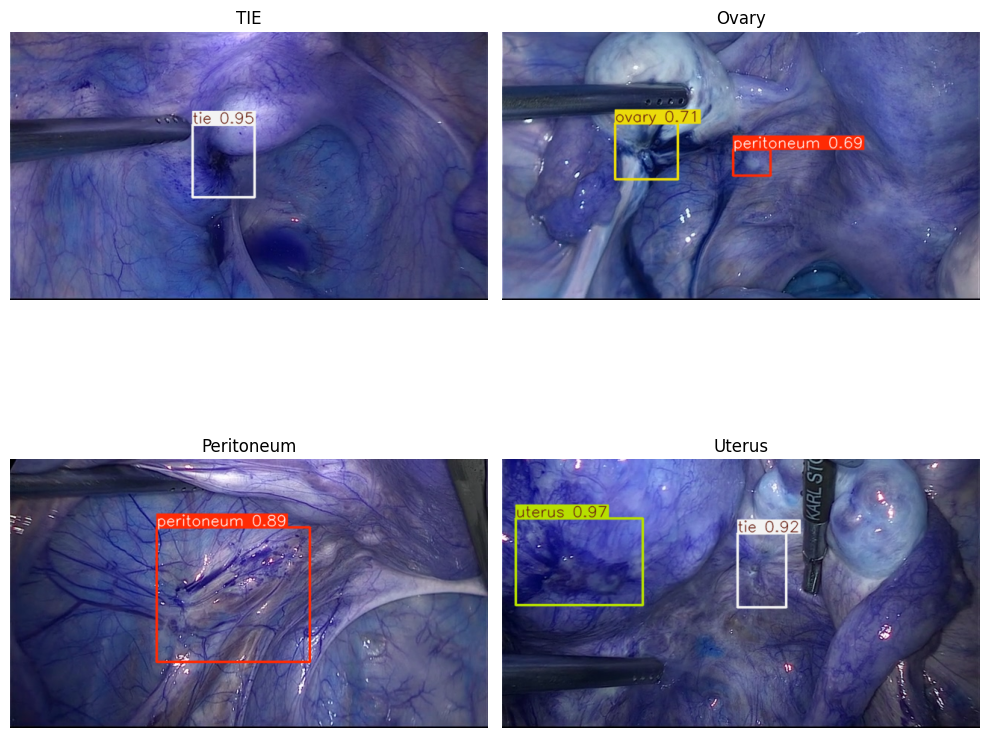

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, (cls, img_path) in enumerate(selected_images.items()):
    r = results[i]
    img = r.plot()  # YOLO draws boxes

    ax = axes[i//2][i%2]
    ax.imshow(img)
    ax.set_title(class_names[cls])
    ax.axis('off')

plt.tight_layout()
plt.savefig("yolo_2x2_grid.png", dpi=300)
plt.show()

In [ ]:
from google.colab import files
files.download("/content/runs/detect/glenda_bbox/lesion/results.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>